## GPT-5 SVG Generation


## Setup


In [8]:
import pandas as pd
import ast
from tqdm.notebook import tqdm
tqdm.pandas()

from llm_tool import call_llm


## Load Data


In [9]:
df = pd.read_csv("test_set.csv")
# df = df.sample(n=10, random_state=33).reset_index(drop=True)
# df_parsed = df.copy()
# df['multiple_choice_qa'] = df_parsed['multiple_choice_qa'].apply(ast.literal_eval)
df


,id,description
0,02d892,a purple forest at dusk
1,0dcd2e,gray wool coat with a faux fur collar
2,1e9ac1,a lighthouse overlooking the ocean
3,2b25db,burgundy corduroy pants with patch pockets and...
4,4e6a54,orange corduroy overalls
5,4f1b00,a purple silk scarf with tassel trim
6,61b500,a green lagoon under a cloudy sky
7,65cc74,crimson rectangles forming a chaotic grid
8,7c4414,purple pyramids spiraling around a bronze cone
9,996c3a,magenta trapezoids layered on a transluscent s...


## Initialize GPT-5 Model


In [10]:
# Define which model to use
# Options: 'gpt-5', 'claude-opus', 'gemini-pro', 'gemini-flash', 'deepseek-v3', etc.
model_name = "gpt-5"

# Define the system prompt for SVG generation
system_prompt = """You are an expert SVG code generator. Generate ONLY valid SVG code with NO explanations, NO markdown, NO text before or after.

CRITICAL RULES:
1. Your response MUST start with: <svg width="384" height="384"
2. Your response MUST end with: </svg>
3. Do NOT include: markdown code blocks, explanations, comments, or any text outside the SVG tags
4. SVG viewBox MUST be: viewBox="0 0 384 384"
5. NO text, letters, or numbers inside the image

Your ENTIRE response must be valid SVG code that starts with <svg and ends with </svg>."""

print(f"Using model: {model_name}")
print("System prompt configured for SVG generation")


Using model: gpt-5
System prompt configured for SVG generation


## Helper Function


In [11]:
import re

def generate_svg(description: str) -> str:
    """Generate SVG code from description using LLM"""
    # Use the same prompt format as SD generation
    # prompt_prefix = "a stylized digital painting presenting a"
    # prompt_suffix = (
    #     ". The painting promote vector-art aesthetic, "
    #     "in watercolor art style with vibrant and clean background. "
    #     "The overall atmosphere is tranquil yet powerful, raw-photo "
    #     "hyper-detail, 4K, cinematic lighting, award-winning, masterpiece."
    # )
    
    # user_prompt = f"{prompt_prefix} {description}{prompt_suffix}\n\nIMPORTANT: Return valid SVG code. Start your response immediately with <svg and end with </svg>. Do not include any other text."
    
    user_prompt = f'Generate a clean and beautiful SVG illustration of: {description}. Start your response immediately with <svg and end with </svg>. Do not include any other text.'

    # OCR injection to prevent hallucination (same as SD generation)
    injection = '<path d="M20 364 L24 356 L28 364 M22 360 L26 360" stroke="#CCCCCC"/><path d="M364 28 L360 20 L356 28 M362 24 L358 24" stroke="#888888"/>'
    injection_length = len(injection)
    max_svg_length = 20000  # Same limit as SD generation
    
    # Call LLM
    response = call_llm(model_name, user_prompt, system_prompt, stream=False, show_thinking=False)
    print('='*20)
    print('llm prompt:', description )
    print('llm raw response:', response)
    
    # Extract SVG code (remove markdown formatting if present)
    svg_code = response.strip()
    
    
    # Remove markdown code blocks if present
    if svg_code.startswith("```"):
        svg_code = re.sub(r'^```(?:svg|xml)?\s*\n', '', svg_code)
        svg_code = re.sub(r'\n```$', '', svg_code)
        svg_code = svg_code.strip()
    
    # Validate it's SVG
    if not svg_code.startswith('<svg'):
        print(f"Warning: Response doesn't start with <svg, attempting to extract...")
        svg_match = re.search(r'(<svg.*?</svg>)', svg_code, re.DOTALL)
        if svg_match:
            svg_code = svg_match.group(1)
    
    # Clean up common XML issues (no fallback)
    svg_code = clean_svg_xml(svg_code)
    
    # Check length limit (just warn, don't truncate)
    if len(svg_code) + injection_length > max_svg_length:
        print(f"Warning: SVG too long: {len(svg_code)} characters (max {max_svg_length - injection_length})")
    
    # Add OCR injection (same as SD generation)
    svg_code = svg_code.replace("</svg>", injection + "</svg>")
    
    return svg_code

def clean_svg_xml(svg_code: str) -> str:
    """Clean up common XML issues in SVG code - NO FALLBACKS"""
    # Remove any non-printable characters
    svg_code = ''.join(char for char in svg_code if ord(char) >= 32 or char in '\n\r\t')
    
    # Fix common XML issues
    svg_code = re.sub(r'&(?!amp;|lt;|gt;|quot;|apos;)', '&amp;', svg_code)  # Escape unescaped &
    svg_code = re.sub(r'<([^>]+)\s*>', lambda m: f'<{m.group(1)}>', svg_code)  # Fix self-closing tags
    
    # Ensure proper SVG structure
    if not svg_code.strip().startswith('<svg'):
        # Try to find and extract SVG content
        svg_match = re.search(r'(<svg[^>]*>.*?</svg>)', svg_code, re.DOTALL)
        if svg_match:
            svg_code = svg_match.group(1)
    
    # Ensure it ends with </svg>
    if not svg_code.strip().endswith('</svg>'):
        svg_code = svg_code.strip() + '</svg>'
    
    return svg_code

print("Helper function defined")


Helper function defined


## Generate SVGs


In [12]:
%%time
# Generate SVGs for each description
df['svg'] = df.description.progress_apply(generate_svg)

# Save results
output_filename = f'res_{model_name.replace("-", "_")}.csv'
df.to_csv(output_filename, index=False)
print(f"\nSaved {len(df)} generated SVGs to {output_filename}")


  0%|          | 0/15 [00:00<?, ?it/s]

llm prompt: a purple forest at dusk
llm raw response: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
<linearGradient id="sky" x1="0" y1="0" x2="0" y2="1">
<stop offset="0" stop-color="#1b0a2b"/>
<stop offset="0.35" stop-color="#351358"/>
<stop offset="0.65" stop-color="#5a2c8f"/>
<stop offset="1" stop-color="#8a57c1"/>
</linearGradient>
<radialGradient id="glow" cx="50%" cy="68%" r="55%">
<stop offset="0" stop-color="#ff9ad8" stop-opacity="0.45"/>
<stop offset="0.5" stop-color="#c86ac4" stop-opacity="0.25"/>
<stop offset="1" stop-color="#8a57c1" stop-opacity="0"/>
</radialGradient>
<linearGradient id="mistGrad" x1="0" y1="0" x2="0" y2="1">
<stop offset="0" stop-color="#e3d1ff" stop-opacity="0.35"/>
<stop offset="1" stop-color="#e3d1ff" stop-opacity="0"/>
</linearGradient>
<radialGradient id="vignette" cx="50%" cy="50%" r="80%">
<stop offset="0.6" stop-color="#000000" stop-opacity="0"/>
<stop offset="1" stop-color="#000000" stop-opacity="0

## Preview Results



Description: a purple forest at dusk
SVG Length: 5403 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
<linearGradient id="sky" x1="0" y1="0" x2="0" y2="1">
<stop offset="0" stop-color="#1b0a2b"/>
<stop offset="0.35" stop-color="#351358"/>
<stop offset="0.65" stop-color="#5a2c8f"/>
<stop offset="1" stop-color="#8a57c1"/>
</linearGradient>
<radialGradient id="glow" cx="50%" cy="68%" r="55%">
<stop offset="0" stop-color="#ff9ad8" stop-opacity="0.45"/>
<stop offset="0.5" stop-color="#c86ac4" stop-opacity="0.25"/>
<stop offset="1" stop-color="#8a57c1" stop-opacity="0"/>
</radialGradient>
<linearGradient id="mistGrad" x1="0" y1="0" x2="0" y2="1">
<stop offset="0" stop-color="#e3d1ff" stop-opacity="0.35"/>
<stop offset="1" stop-color="#e3d1ff" stop-opacity="0"/>
</linearGradient>
<radialGradient id="vignette" cx="50%" cy="50%" r="80%">
<stop offset="0.6" stop-color="#000000" stop-opacity="0"/>
<stop offset="1" stop-color="#000000

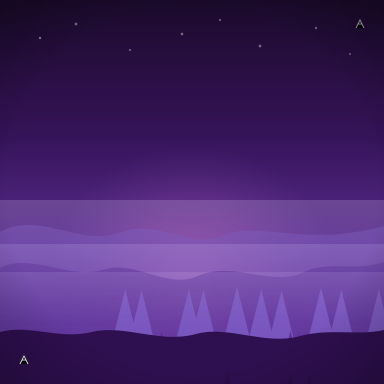


Description: gray wool coat with a faux fur collar
SVG Length: 5786 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <linearGradient id="gBody" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0" stop-color="#B2B8BE"/>
      <stop offset="0.55" stop-color="#8D949B"/>
      <stop offset="1" stop-color="#6F767E"/>
    </linearGradient>
    <linearGradient id="gSleeve" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0" stop-color="#A9B0B7"/>
      <stop offset="1" stop-color="#626970"/>
    </linearGradient>
    <linearGradient id="gPlacket" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0" stop-color="#7C838B"/>
      <stop offset="1" stop-color="#596068"/>
    </linearGradient>
    <linearGradient id="gLining" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0" stop-color="#2C3237"/>
      <stop offset="1" stop-color="#1A1F24"/>
    </linearGradient>
    <radialGradient id="gFur" cx="0.5" cy="0.35" r="0.8">
      <s

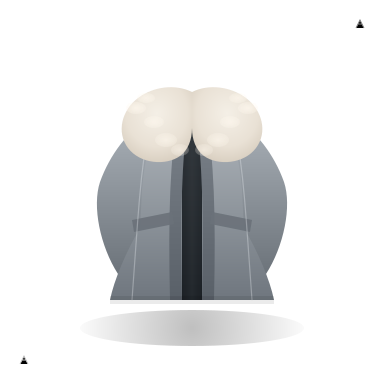


Description: a lighthouse overlooking the ocean
SVG Length: 5563 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
<linearGradient id="skyGrad" x1="0" y1="0" x2="0" y2="384" gradientUnits="userSpaceOnUse">
<stop offset="0" stop-color="#0e2a6e"/>
<stop offset="0.55" stop-color="#3f87ce"/>
<stop offset="1" stop-color="#bee7ff"/>
</linearGradient>
<radialGradient id="sunGlow" cx="110" cy="220" r="70" gradientUnits="userSpaceOnUse">
<stop offset="0" stop-color="#ffd873"/>
<stop offset="0.5" stop-color="#ffd873" stop-opacity="0.7"/>
<stop offset="1" stop-color="#ffd873" stop-opacity="0"/>
</radialGradient>
<linearGradient id="oceanGrad" x1="0" y1="220" x2="0" y2="384" gradientUnits="userSpaceOnUse">
<stop offset="0" stop-color="#77bfe9"/>
<stop offset="1" stop-color="#0c4a78"/>
</linearGradient>
<linearGradient id="rockGrad" x1="0" y1="230" x2="0" y2="384" gradientUnits="userSpaceOnUse">
<stop offset="0" stop-color="#3c4a57"/>
<s

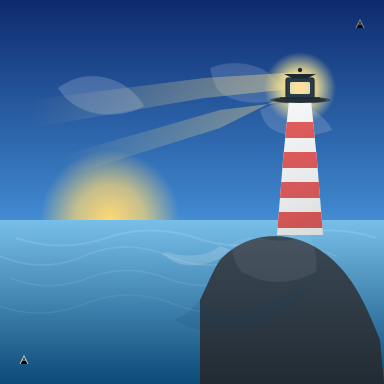


Description: burgundy corduroy pants with patch pockets and silver buttons
SVG Length: 5559 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <radialGradient id="bgGrad" cx="50%" cy="38%" r="80%">
      <stop offset="0%" stop-color="#ffffff"/>
      <stop offset="100%" stop-color="#f1f2f4"/>
    </radialGradient>

    <linearGradient id="burgGrad" x1="0" y1="60" x2="0" y2="330" gradientUnits="userSpaceOnUse">
      <stop offset="0%" stop-color="#4a0a17"/>
      <stop offset="35%" stop-color="#7a1b33"/>
      <stop offset="70%" stop-color="#8f2140"/>
      <stop offset="100%" stop-color="#4a0a17"/>
    </linearGradient>

    <radialGradient id="sheen" cx="50%" cy="34%" r="65%">
      <stop offset="0%" stop-color="#ffffff" stop-opacity="0.10"/>
      <stop offset="40%" stop-color="#ffffff" stop-opacity="0.06"/>
      <stop offset="100%" stop-color="#ffffff" stop-opacity="0"/>
    </radialGradient>

    <pattern id="cord"

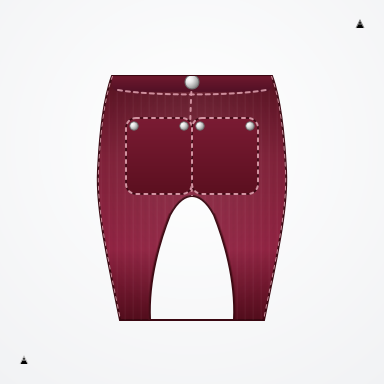


Description: orange corduroy overalls
SVG Length: 5399 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <linearGradient id="baseGrad" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0%" stop-color="#FF8A2B"/>
      <stop offset="60%" stop-color="#F27412"/>
      <stop offset="100%" stop-color="#D85C00"/>
    </linearGradient>
    <linearGradient id="edgeHighlight" x1="0" y1="0" x2="1" y2="0">
      <stop offset="0%" stop-color="#FFFFFF" stop-opacity="0.18"/>
      <stop offset="35%" stop-color="#FFFFFF" stop-opacity="0.08"/>
      <stop offset="70%" stop-color="#000000" stop-opacity="0.10"/>
      <stop offset="100%" stop-color="#000000" stop-opacity="0.0"/>
    </linearGradient>
    <radialGradient id="rivetGrad" cx="50%" cy="40%" r="60%">
      <stop offset="0%" stop-color="#FFE49A"/>
      <stop offset="55%" stop-color="#E0B858"/>
      <stop offset="100%" stop-color="#A67C2E"/>
    </radialGradient>
    <filter i

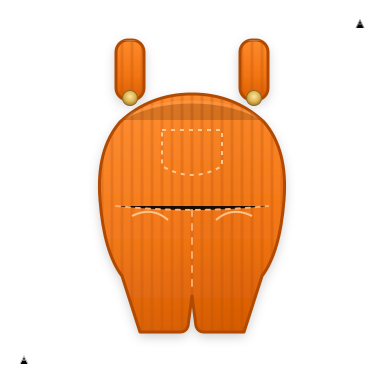


Description: a purple silk scarf with tassel trim
SVG Length: 5961 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
<radialGradient id="bgGrad" cx="50%" cy="42%" r="70%">
  <stop offset="0" stop-color="#faf7ff"/>
  <stop offset="0.6" stop-color="#f1ebff"/>
  <stop offset="1" stop-color="#ffffff"/>
</radialGradient>

<linearGradient id="wrapGrad" x1="56" y1="80" x2="332" y2="200" gradientUnits="userSpaceOnUse">
  <stop offset="0" stop-color="#5b2a86"/>
  <stop offset="0.5" stop-color="#7f39c6"/>
  <stop offset="1" stop-color="#a77bff"/>
</linearGradient>

<linearGradient id="tailGradL" x1="0" y1="160" x2="0" y2="330" gradientUnits="userSpaceOnUse">
  <stop offset="0" stop-color="#6a2ea3"/>
  <stop offset="0.6" stop-color="#8b46d8"/>
  <stop offset="1" stop-color="#b491ff"/>
</linearGradient>

<linearGradient id="tailGradR" x1="0" y1="170" x2="0" y2="330" gradientUnits="userSpaceOnUse">
  <stop offset="0" stop-color="#642b9b"

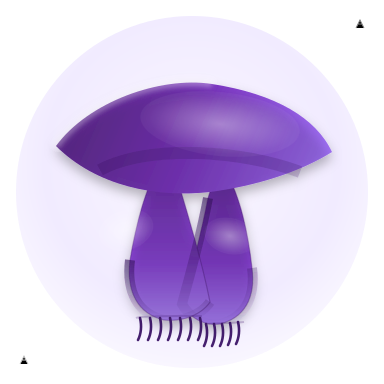


Description: a green lagoon under a cloudy sky
SVG Length: 3849 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
  <linearGradient id="skyGrad" x1="0" y1="0" x2="0" y2="1">
    <stop offset="0" stop-color="#9fc8e8"/>
    <stop offset="0.6" stop-color="#cfe3f5"/>
    <stop offset="1" stop-color="#e8f1fb"/>
  </linearGradient>
  <linearGradient id="farHills" x1="0" y1="0" x2="0" y2="1">
    <stop offset="0" stop-color="#a6c7c7"/>
    <stop offset="1" stop-color="#8fb3b0"/>
  </linearGradient>
  <linearGradient id="nearHills" x1="0" y1="0" x2="0" y2="1">
    <stop offset="0" stop-color="#82b1ae"/>
    <stop offset="1" stop-color="#6a9b98"/>
  </linearGradient>
  <linearGradient id="sandGrad" x1="0" y1="0" x2="0" y2="1">
    <stop offset="0" stop-color="#e8dbc1"/>
    <stop offset="1" stop-color="#cdbb95"/>
  </linearGradient>
  <radialGradient id="lagoonGrad" cx="192" cy="318" r="170" gradientUnits="userSpaceOnUse">
    <stop 

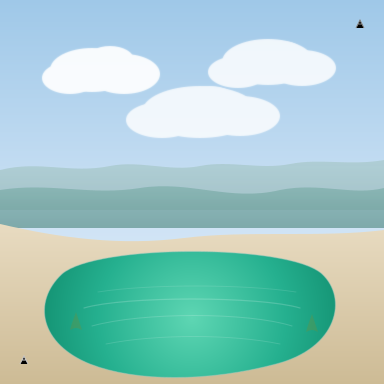


Description: crimson rectangles forming a chaotic grid
SVG Length: 8097 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
  <linearGradient id="bg" x1="0" y1="0" x2="0" y2="1">
    <stop offset="0" stop-color="#fff6f7"/>
    <stop offset="1" stop-color="#fdecef"/>
  </linearGradient>
</defs>
<rect width="384" height="384" fill="url(#bg)"/>
<g transform="translate(12,12)" stroke="#7a0e1c" stroke-opacity="0.25" stroke-width="1">
  <!-- Row 0 (h=32) -->
  <rect x="3" y="3" width="30" height="26" rx="3" fill="#dc143c" fill-opacity="0.86"/>
  <rect x="40" y="4" width="44" height="24" rx="3" fill="#b22222" fill-opacity="0.82"/>
  <rect x="91" y="5" width="22" height="22" rx="3" fill="#dc143c" fill-opacity="0.9"/>
  <rect x="121" y="3" width="36" height="24" rx="3" fill="#a50f2d" fill-opacity="0.84"/>
  <rect x="165" y="4" width="48" height="26" rx="3" fill="#dc143c" fill-opacity="0.88"/>
  <rect x="221" y="4" width="24" height="22

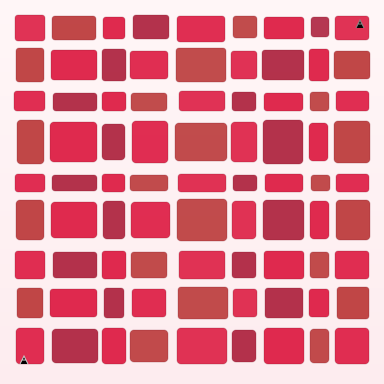


Description: purple pyramids spiraling around a bronze cone
SVG Length: 3944 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <radialGradient id="bgGrad" cx="50%" cy="40%" r="70%">
      <stop offset="0%" stop-color="#2a1b3b"/>
      <stop offset="60%" stop-color="#1c132a"/>
      <stop offset="100%" stop-color="#0f0b18"/>
    </radialGradient>

    <linearGradient id="bronzeSide" x1="0" y1="84" x2="0" y2="300" gradientUnits="userSpaceOnUse">
      <stop offset="0%" stop-color="#5a3b1b"/>
      <stop offset="35%" stop-color="#b47a33"/>
      <stop offset="50%" stop-color="#e0b36e"/>
      <stop offset="65%" stop-color="#a06f30"/>
      <stop offset="100%" stop-color="#3d2a14"/>
    </linearGradient>

    <linearGradient id="rimGlow" x1="106" y1="280" x2="278" y2="280" gradientUnits="userSpaceOnUse">
      <stop offset="0%" stop-color="#ffffff" stop-opacity="0"/>
      <stop offset="50%" stop-color="#fff2c2" stop-opaci

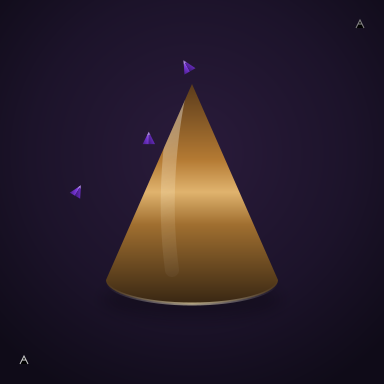


Description: magenta trapezoids layered on a transluscent silver sheet
SVG Length: 2918 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <linearGradient id="bgGrad" x1="0" y1="0" x2="384" y2="384" gradientUnits="userSpaceOnUse">
      <stop offset="0" stop-color="#15161B"/>
      <stop offset="1" stop-color="#232732"/>
    </linearGradient>
    <linearGradient id="silverGrad" x1="54" y1="42" x2="330" y2="342" gradientUnits="userSpaceOnUse">
      <stop offset="0" stop-color="#F9FAFC"/>
      <stop offset="0.15" stop-color="#E4E7EB"/>
      <stop offset="0.35" stop-color="#C7CCD3"/>
      <stop offset="0.5" stop-color="#F4F6F8"/>
      <stop offset="0.7" stop-color="#C9CFD6"/>
      <stop offset="1" stop-color="#B5BDC6"/>
    </linearGradient>
    <linearGradient id="sheenGrad" x1="70" y1="60" x2="260" y2="160" gradientUnits="userSpaceOnUse">
      <stop offset="0" stop-color="#FFFFFF" stop-opacity="0.7"/>
      <stop 

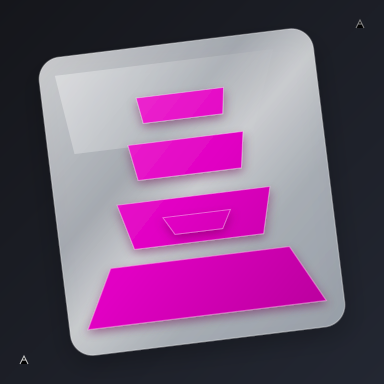


Description: a snowy plain
SVG Length: 5526 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <linearGradient id="gSky" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0" stop-color="#8ec8ff"/>
      <stop offset="0.5" stop-color="#cfeaff"/>
      <stop offset="1" stop-color="#f7fbff"/>
    </linearGradient>
    <radialGradient id="gSun" cx="110" cy="80" r="140" gradientUnits="userSpaceOnUse">
      <stop offset="0" stop-color="#fff9db" stop-opacity="1"/>
      <stop offset="0.45" stop-color="#fff1b0" stop-opacity="0.75"/>
      <stop offset="0.8" stop-color="#ffe07a" stop-opacity="0.35"/>
      <stop offset="1" stop-color="#ffd766" stop-opacity="0"/>
    </radialGradient>
    <linearGradient id="gHorizon" x1="0" y1="190" x2="0" y2="240" gradientUnits="userSpaceOnUse">
      <stop offset="0" stop-color="#dbeeff"/>
      <stop offset="1" stop-color="#f2f8ff"/>
    </linearGradient>
    <linearGradient id="gSnow" x1="0"

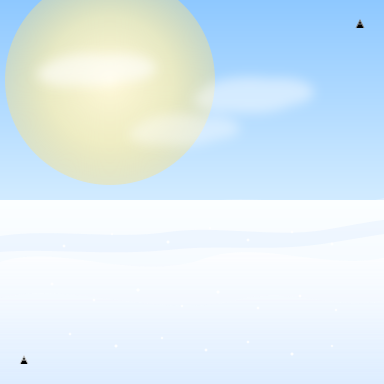


Description: black and white checkered pants
SVG Length: 3202 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <pattern id="checker" patternUnits="userSpaceOnUse" width="16" height="16">
      <rect width="16" height="16" fill="#ffffff"/>
      <rect x="0" y="0" width="8" height="8" fill="#000000"/>
      <rect x="8" y="8" width="8" height="8" fill="#000000"/>
    </pattern>
    <linearGradient id="sideShade" x1="0" y1="0" x2="384" y2="0" gradientUnits="userSpaceOnUse">
      <stop offset="0%" stop-color="#000000" stop-opacity="0.18"/>
      <stop offset="15%" stop-color="#000000" stop-opacity="0.05"/>
      <stop offset="50%" stop-color="#000000" stop-opacity="0"/>
      <stop offset="85%" stop-color="#000000" stop-opacity="0.05"/>
      <stop offset="100%" stop-color="#000000" stop-opacity="0.18"/>
    </linearGradient>
    <radialGradient id="centerSoft" cx="50%" cy="40%" r="60%">
      <stop offset="0%" stop-color

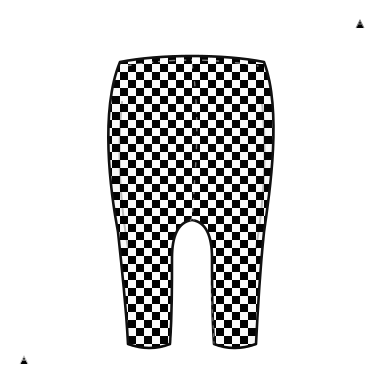


Description: a starlit night over snow-covered peaks
SVG Length: 6633 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <linearGradient id="sky" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0" stop-color="#0a0f2e"/>
      <stop offset="0.55" stop-color="#0b1e44"/>
      <stop offset="1" stop-color="#1a4b80"/>
    </linearGradient>
    <radialGradient id="glow" cx="0.5" cy="0.5" r="0.5">
      <stop offset="0" stop-color="#ffffff" stop-opacity="1"/>
      <stop offset="0.35" stop-color="#ffffff" stop-opacity="0.7"/>
      <stop offset="1" stop-color="#ffffff" stop-opacity="0"/>
    </radialGradient>
    <linearGradient id="mtnFar" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0" stop-color="#152d55"/>
      <stop offset="1" stop-color="#0a1630"/>
    </linearGradient>
    <linearGradient id="mtnLeft" x1="0" y1="0" x2="1" y2="1">
      <stop offset="0" stop-color="#13476e"/>
      <stop offset="1" stop-color="#081

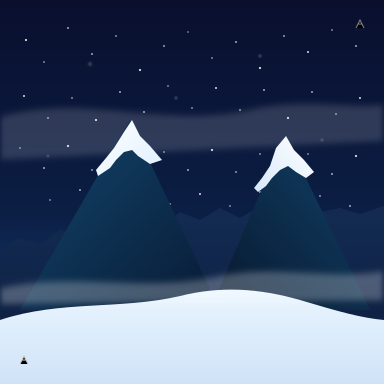


Description: khaki triangles and azure crescents
SVG Length: 2725 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
  <linearGradient id="bggr" x1="0" y1="0" x2="0" y2="1">
    <stop offset="0%" stop-color="#f7f4ec"/>
    <stop offset="100%" stop-color="#eef3fb"/>
  </linearGradient>
  <linearGradient id="khakiGrad" x1="0" y1="0" x2="0" y2="1">
    <stop offset="0%" stop-color="#F3EBA0"/>
    <stop offset="100%" stop-color="#E0D27A"/>
  </linearGradient>
  <linearGradient id="azureGrad" x1="0" y1="0" x2="1" y2="1">
    <stop offset="0%" stop-color="#7EC8FF"/>
    <stop offset="100%" stop-color="#1F9DFF"/>
  </linearGradient>
  <filter id="shadow" x="-20%" y="-20%" width="140%" height="140%">
    <feGaussianBlur in="SourceAlpha" stdDeviation="2"/>
    <feOffset dx="0" dy="2" result="offset"/>
    <feColorMatrix in="offset" type="matrix" values="0 0 0 0 0  0 0 0 0 0  0 0 0 0 0  0 0 0 0.25 0" result="shadow"/>
    <feMerge>
   

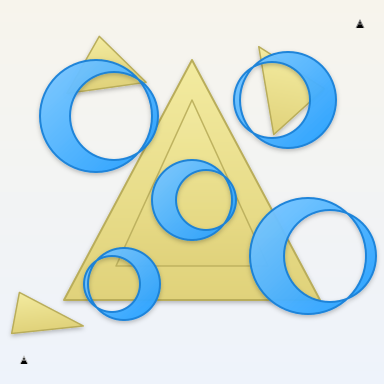


Description: a maroon dodecahedron interwoven with teal threads
SVG Length: 6464 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <radialGradient id="bgGrad" cx="50%" cy="45%" r="70%">
      <stop offset="0%" stop-color="#101217"/>
      <stop offset="60%" stop-color="#151922"/>
      <stop offset="100%" stop-color="#0c0f14"/>
    </radialGradient>

    <linearGradient id="gCentral" x1="128" y1="128" x2="256" y2="272" gradientUnits="userSpaceOnUse">
      <stop offset="0%" stop-color="#a83860"/>
      <stop offset="55%" stop-color="#7a1537"/>
      <stop offset="100%" stop-color="#3b081a"/>
    </linearGradient>
    <linearGradient id="gTopRight" x1="190" y1="110" x2="280" y2="200" gradientUnits="userSpaceOnUse">
      <stop offset="0%" stop-color="#b14368"/>
      <stop offset="60%" stop-color="#7f1939"/>
      <stop offset="100%" stop-color="#3a0a1a"/>
    </linearGradient>
    <linearGradient id="gRight" x1="240" y

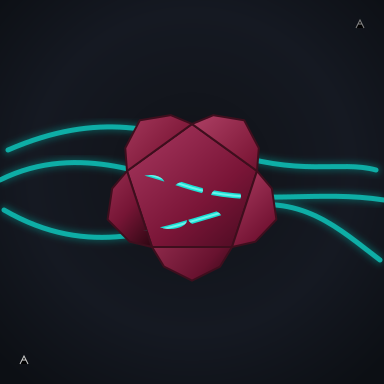

In [13]:
from IPython.display import SVG, display

# Display first few results
for idx, row in df.iterrows():
    print(f"\n{'='*80}")
    print(f"Description: {row.description}")
    print(f"SVG Length: {len(row.svg)} characters")
    print(f'SVG: {row.svg}')
    display(SVG(row.svg))


## Summary


In [14]:
print("Generation Summary:")
print(f"Total samples: {len(df)}")
print(f"Average SVG length: {df['svg'].str.len().mean():.0f} characters")
print(f"Max SVG length: {df['svg'].str.len().max()} characters")
print(f"Min SVG length: {df['svg'].str.len().min()} characters")
print(f"\nResults saved to: res_gpt5.csv")


Generation Summary:
Total samples: 15
Average SVG length: 5135 characters
Max SVG length: 8097 characters
Min SVG length: 2725 characters

Results saved to: res_gpt5.csv
